<h1>Universal Workflow of DLWP 4.5</h1>

<h2> 4.5.1 Defining the problem and dataset </h2>

For this exploratory, I will be using a dataset on Titanic obtained from Kaggle [1], a reliable online data science platform with a large community. Titanic has long and widely been known as one of the greatest tragedies in maritime history. The goal of the exploratory is to build a neural network that can predict the survival rate of passengers based on a variety of suitable features using the universal workflow of DLWP.

In [38]:
# Install tensorflow
!pip install tensorflow

In [90]:
import tensorflow as tf
import pandas as pd
import numpy as np

# Read the CSV file
df = pd.read_csv('Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


The dataset exists as a CSV file containing a total of 891 records with 12 structured columns, namely, PassengerId, Survived (0 = Dead, 1 = Survived), Pclass (Passenger class on ship), Name, Sex, Age, SibSp (Number of siblings/spouses on ship), Parch (Number of parents/children on ship), Ticket, Fare, Cabin and Embarked (C = Cherbourg, Q = Queenstown, S = Southampton).

The dataset will be checked for duplicate rows and missing values as follows.

In [92]:
# Check for duplicate rows
duplicate = df[df.duplicated()]
duplicate

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [94]:
# Check for missing values
null = df[df.isnull().any(axis=1)]
null

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


<h2>4.5.2 Choosing a measure of success</h2>

A large proportion of missing values are found in Cabin as shown above. The values of Cabin are also unnecessary in this exploratory along with that of PassengerId, Name and Ticket. These columns are to be dropped and missing values are checked again as follows. The remaining columns (Pclass, Sex, Age, SibSp, Parch, Fare and Embarked) will all be used to predict the survival rate (Survived) later on. This is a binary classification problem as the target variable Survived only has two possible outcomes of dead or survived. A metric of accuracy will be used.

In [96]:
# Drop unnecessary columns
df = df.drop(['Cabin', 'PassengerId', 'Name', 'Ticket'], axis=1)

# Check again for missing values
null = df[df.isnull().any(axis=1)]
null

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
5,0,3,male,NaN,0,0,8.4583,Q
17,1,2,male,NaN,0,0,13.0000,S
19,1,3,female,NaN,0,0,7.2250,C
26,0,3,male,NaN,0,0,7.2250,C
28,1,3,female,NaN,0,0,7.8792,Q
...,...,...,...,...,...,...,...,...
859,0,3,male,NaN,0,0,7.2292,C
863,0,3,female,NaN,8,2,69.5500,S
868,0,3,male,NaN,0,0,9.5000,S
878,0,3,male,NaN,0,0,7.8958,S


In [98]:
# Now large proportion of missing values are found in Age (Rectify later)
# Get all other columns except Age
columns_except_age = [col for col in df.columns if col != 'Age']

# Check missing values in any columns other than Age
nan_rows_except_age = df[df[columns_except_age].isna().any(axis=1)]
nan_rows_except_age

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
61,1,1,female,38.0,0,0,80.0,NaN
829,1,1,female,62.0,0,0,80.0,NaN


In [100]:
# Manually input missing values 
df.loc[df.index == 61, 'Embarked'] = 'S'
df.loc[df.index == 829, 'Embarked'] = 'S'

In [102]:
# Confirm no more missing values are left
nan_rows_except_age = df[df[columns_except_age].isna().any(axis=1)]
nan_rows_except_age

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked


A large proportion of missing values are found in Age as shown above and this will be rectified under the preprocessing function later. The remaining 2 missing values are found to be in records 61 and 829 under Embarked and these can be manually inputed through searching from the web [2]

<h2>4.5.3 Deciding on an evaluation protocol</h2>

Given the small dataset size of 891 samples, hold-out validation (80% train, 20% validation) is the most suitable here.

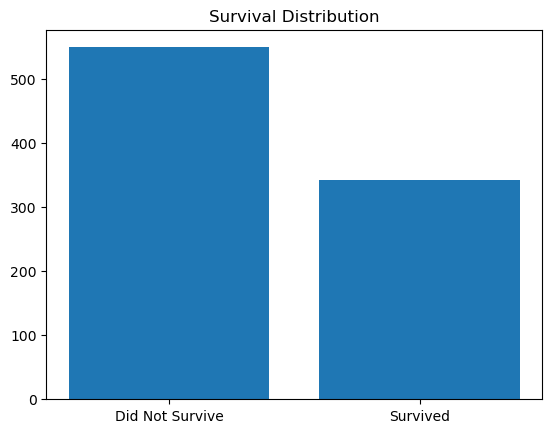

Baseline Accuracy (majority class): 0.6162


In [104]:
import matplotlib.pyplot as plt

# Calculate and display the distribution of the target variable 
def plot_class_distribution(df):
    survival_counts = df['Survived'].value_counts()
    # Plot a bar graph
    plt.bar(['Did Not Survive', 'Survived'], survival_counts)
    plt.title('Survival Distribution')
    plt.show()
    # Calculate baseline accuracy
    baseline_acc = survival_counts.max() / len(df)
    print(f"Baseline Accuracy (majority class): {baseline_acc:.4f}")
    return baseline_acc
    
baseline = plot_class_distribution(df)

In [106]:
from sklearn.model_selection import train_test_split

# Hold-out validation 
def split_data(df):
    # Separate features and target variable
    X = df.drop('Survived', axis=1)
    y = df['Survived']

    # Train-validation split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Training Shape:", X_train.shape)
    print("Validation Shape:", X_val.shape)
    return X_train, X_val, y_train, y_val
    
X_train, X_val, y_train, y_val = split_data(df)

Training Shape: (712, 7)
Validation Shape: (179, 7)


As shown above, the Survival distribution shows a larger proportion of passengers having not survived the disaster. The baseline accuracy is calculated to be 0.6162, providing a platform to improve it. The training shape is (712, 7) and the validation shape is (179, 7), a 80:20 ratio after splitting as mentioned earlier.

<h2>4.5.4 Preparing the data</h2>

The data is preprocessed by encoding categorical variables, imputing missing values and normalizing features through scaling to complement the neural network. Label encoding is used for Sex as it is a binary variable while one-hot encoding is used for Embarked as it has 3 different categories. Median is used for Age as it is robust to outliers and preserves the data. [3]

In [108]:
from sklearn.preprocessing import StandardScaler

# Data preprocessing 
def preprocess_data(X_train, X_val):
    # Encode categorical variables
    # Label encoding 
    X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1}) 
    X_val['Sex'] = X_val['Sex'].map({'male': 0, 'female': 1})
    # One-hot encoding 
    X_train = pd.get_dummies(X_train, columns=['Embarked'], drop_first=True)
    X_val = pd.get_dummies(X_val, columns=['Embarked'], drop_first=True)

    # Impute missing values as mentioned earlier
    X_train['Age'] = X_train['Age'].fillna(X_train['Age'].median())
    X_val['Age'] = X_val['Age'].fillna(X_val['Age'].median())

    # Scale numerical features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    print("Processed Training Shape:", X_train.shape)
    return X_train, X_val

# Execution
X_train, X_val = preprocess_data(X_train, X_val)

Processed Training Shape: (712, 8)


<h2>4.5.5 Developing a model that does better than the baseline</h2>

Since it is a binary classification problem, an initial simple neural network of 2 hidden dense layers with 16 units each (relu activation) and a sigmoid output layer will be constructed as follows. RMSprop and binary cross-entropy are suitable for use when compiling the model [4]

In [110]:
import tensorflow.keras.models as models
import tensorflow.keras.layers as layers

# Build initial model 
def build_model(X_train):
    tf.keras.backend.clear_session()
    # Define model
    model = models.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    model.add(layers.Dense(16, activation='relu'))
    model.add(layers.Dense(16, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile model
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Execution
model = build_model(X_train)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5783 - loss: 0.7043 - val_accuracy: 0.6536 - val_loss: 0.6327
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6686 - loss: 0.6218 - val_accuracy: 0.7598 - val_loss: 0.5701
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7496 - loss: 0.5817 - val_accuracy: 0.7877 - val_loss: 0.5248
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7492 - loss: 0.5629 - val_accuracy: 0.8045 - val_loss: 0.4895
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8087 - loss: 0.5068 - val_accuracy: 0.8324 - val_loss: 0.4616
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7878 - loss: 0.5016 - val_accuracy: 0.8212 - val_loss: 0.4417
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7983 - loss: 0.4799 - val_accuracy: 0.8212 - val_loss: 0.4273
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8001 - loss: 0.4559 - val_accuracy: 0.8212 - val_lo

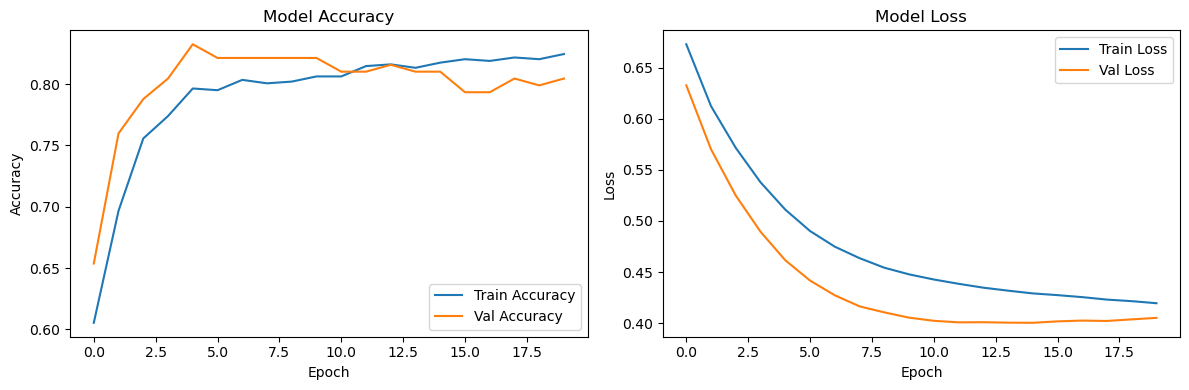

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8150 - loss: 0.3970
Baseline Accuracy: 0.6162
Model Validation Accuracy: 0.8045
Model beats the baseline!


In [112]:
# Train the model 
def train_and_plot(model, X_train, y_train, X_val, y_val, baseline):
    # Fit the model and evaluate validation data
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

    # Final validation accuracy and loss
    print("Final validation accuracy from history:", history.history['val_accuracy'][-1])
    print("Final validation loss from history:", history.history['val_loss'][-1])

    # Plot model accuracy graph
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Plot model loss graph
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Compare validation accuracy with baseline accuracy
    val_loss, val_acc = model.evaluate(X_val, y_val)
    print(f"Baseline Accuracy: {baseline:.4f}")
    print(f"Model Validation Accuracy: {val_acc:.4f}")
    if val_acc > baseline:
        print("Model beats the baseline!")
    else:
        print("Model does not beat the baseline.")
    
    return history, val_acc

# Execution
history, val_acc = train_and_plot(model, X_train, y_train, X_val, y_val, baseline)

The model is trained for 20 epochs with a batch size of 32. As shown above in the model accuracy graph above, the training accuracy rose from around 0.60 to 0.83, while validation accuracy stabilized at 0.8045 which beats the baseline accuracy of 0.6162. It can be deduced that the model has effectively learnt the survival rate. On the other had, the model loss curves show a sharp decline; from around 0.67 to 0.55 for the training loss curve and from around 0.64 to 0.48 for the validation loss curve in the first 3 epochs. There is also a slight upward trend in validation loss after around epoch 15 which indicates the prescence of mild overfitting.

<h2>4.5.6 Developing a model that overfits</h2>

In order to further explore the capacity of the neural network, a larger model of 3 hidden dense layers will be constructed for the purpose of overfitting before regularization. 2 of the dense layers have 64 units each while the last one has 32 units.

In [115]:
# Build larger model
def build_larger_model(X_train):
    tf.keras.backend.clear_session()
    # Define model
    model = models.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile model
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Execute
larger_model = build_larger_model(X_train)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6606 - loss: 0.6259 - val_accuracy: 0.7709 - val_loss: 0.4992
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8117 - loss: 0.4614 - val_accuracy: 0.8101 - val_loss: 0.4451
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8087 - loss: 0.4402 - val_accuracy: 0.8212 - val_loss: 0.4338
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8327 - loss: 0.3971 - val_accuracy: 0.8045 - val_loss: 0.4294
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8425 - loss: 0.3973 - val_accuracy: 0.8045 - val_loss: 0.4393
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8471 - loss: 0.3798 - val_accuracy: 0.7989 - val_loss: 0.4353
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8336 - loss: 0.4071 - val_accuracy: 0.8101 - val_loss: 0.4362
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8335 - loss: 0.3896 - val_accuracy: 0.8045 - val_loss

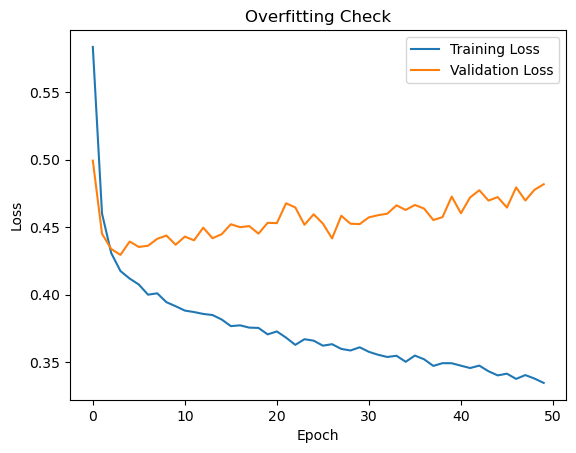

In [117]:
# Train the model
def train_and_check_overfitting(larger_model, X_train, y_train, X_val, y_val):
    # Fit the model and evaluate validation data
    history = larger_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))
    
    # Final validation loss
    print("Final validation loss from history:", history.history['val_loss'][-1])
    
    # Plot overfitting check graph
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Overfitting Check')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    return history

# Execute
history = train_and_check_overfitting(larger_model, X_train, y_train, X_val, y_val)

The model is trained for a larger number of epochs at 50 with a same batch size of 32. As shown above, the overfitting check graph shows overfitting at around 10 epochs with the validation loss increasing from around 0.44 to 0.48, setting the basis for regularization next.

<h2>4.5.7 Regularizing the model</h2>

With overfitting confirmed in the larger model earlier, regularization can be implemented to improve the robustness. 50% dropout will be added to each of the hidden dense layer in the previous architecture to deactivate units during training which aims to reduce overfitting.

In [119]:
# Build final model
def build_final_model(X_train):
    tf.keras.backend.clear_session()
    # Define model and add Dropout
    model = models.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile model
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Execution
final_model = build_final_model(X_train)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4951 - loss: 0.7617 - val_accuracy: 0.7486 - val_loss: 0.6200
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6232 - loss: 0.6626 - val_accuracy: 0.7654 - val_loss: 0.5652
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6915 - loss: 0.5968 - val_accuracy: 0.7542 - val_loss: 0.5275
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7164 - loss: 0.5776 - val_accuracy: 0.7542 - val_loss: 0.4980
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7098 - loss: 0.5729 - val_accuracy: 0.8045 - val_loss: 0.4761
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7522 - loss: 0.5374 - val_accuracy: 0.8045 - val_loss: 0.4584
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7501 - loss: 0.5538 - val_accuracy: 0.7933 - val_loss: 0.4489
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7740 - loss: 0.5537 - val_accuracy: 0.7933 - val_los

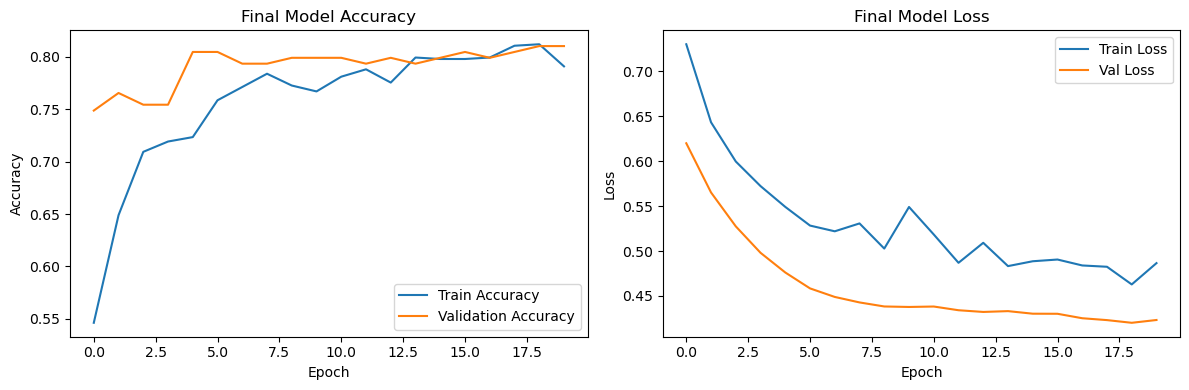

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8213 - loss: 0.4095
Baseline Accuracy: 0.6162
Model Validation Accuracy: 0.8101
Model beats the baseline!


In [121]:
# Train the model
def train_and_evaluate_final_model(final_model, X_train, y_train, X_val, y_val, baseline):
    # Fit the model and evaluate validation data
    history = final_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

    # Plot final model accuracy graph
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Final Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Plot final model loss graph
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Final Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Compare validation accuracy with baseline accuracy
    val_loss, val_acc = final_model.evaluate(X_val, y_val)
    print(f"Baseline Accuracy: {baseline:.4f}")
    print(f"Model Validation Accuracy: {val_acc:.4f}")
    if val_acc > baseline:
        print("Model beats the baseline!")
    else:
        print("Model does not beat the baseline.")

    return history, val_acc

# Execution
history, val_acc = train_and_evaluate_final_model(final_model, X_train, y_train, X_val, y_val, baseline)

The final model is also trained for 20 epochs with a batch size of 32. As shown above in the final model accuracy graph above, the training accuracy rose from around 0.55 to 0.81, while validation accuracy stabilized at 0.8101 which also beats the baseline accuracy of 0.6162. It can be deduced that the model has improved in learning the survival rate with a slightly higher score of 0.8101 as compared to the initial model's score of 0.8045. On the other had, the final model loss curves similarly show a sharp decline; from around 0.73 to 0.58 for the training loss curve and from around 0.62 to 0.50 for the validation loss curve in the first 3 epochs. Overfitting is eliminated as there is no upward trend of the validation loss curve now. This shows the effectiveness of regularization through dropout on the model and the final model successfully beats the baseline with an improved performance, achieving the goal of predicting passenger survival rate of the Titanic

<h2>References</h2>


[1] https://www.kaggle.com/datasets/yasserh/titanic-dataset

[2] https://www.encyclopedia-titanica.org/titanic-survivors/

[3] DLWP 4.3: Data Preprocessing

[4] DLWP 4.4: Model Size/Capacity